# 0. Imports & Reproducibility

In [2]:
import random
import re
from collections import Counter, defaultdict
from pathlib import Path

import community as community_louvain
import faiss
import networkx as nx
import numpy as np
import pandas as pd
import polars as pl
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# 1. Download and Store Dataset

In [4]:
def ingest_reddit_data(
    subreddit_key: str, n_rows: int = 1_000_000, force_rerun: bool = False
) -> Path:
    """
    Orchestrates the ETL process for a specific subreddit's comment data.

    Args:
        subreddit_key: Dictionary key from 'splits' (e.g., 'changemyview').
        n_rows: Maximum records to process for the local sample.
        force_rerun: If True, bypasses existence check and overwrites existing parquet file.

    Returns:
        Path to the processed Parquet file.
    """
    out_path = Path(f"data/processed/{subreddit_key}_sample.parquet")

    # Idempotency check: Skip heavy network I/O if the target file is already present
    if out_path.exists() and not force_rerun:
        print(f"Skipping ingestion: Local cache found at {out_path}")
        return out_path

    out_path.parent.mkdir(parents=True, exist_ok=True)

    # Define schema subset based on downstream analytical requirements
    feature_cols = [
        "author",
        "body",
        "created_utc",
        "id",
        "link_id",
        "name",
        "parent_id",
        "score",
        "controversiality",
        "total_awards_received",
    ]
    splits = {
        "changemyview": "data/changemyview-*-of-*.parquet",
    }

    print(f"Streaming data from HuggingFace for: r/{subreddit_key}...")

    # Execute lazy-evaluated ETL pipeline
    try:
        (
            pl.scan_parquet(
                f"hf://datasets/HuggingFaceGECLM/REDDIT_comments/{splits[subreddit_key]}"
            )
            .select(feature_cols)
            # Filter out deleted/removed content to maintain high data quality for NLP tasks
            .filter(~pl.col("body").is_in(["[deleted]", "[removed]"]))
            .limit(n_rows)
            # Stream directly to disk using ZSTD to balance compression ratio and write speed
            .sink_parquet(out_path, compression="zstd")
        )
        print(f"Successfully wrote {n_rows} rows to {out_path}")
    except KeyError:
        raise ValueError(f"Subreddit '{subreddit_key}' not found in defined splits.")
    except Exception as e:
        print(f"Pipeline failed: {e}")
        raise

    return out_path


# --- Execution Control ---
# Toggle 'force_rerun' if the upstream data schema changes or a larger sample is needed
OUT = ingest_reddit_data("changemyview", n_rows=1_000_000, force_rerun=False)

Skipping ingestion: Local cache found at data/processed/changemyview_sample.parquet


# 2. Load Data from Parquet File

In [5]:
df = (
    # Scan the metadata and define the lazy query plan
    pl.scan_parquet("data/processed/changemyview_sample.parquet")
    # Constrain sample size for rapid local prototyping
    .head(100000)
    # Trigger execution and load into memory
    .collect()
    # Bridge to Pandas for ecosystem compatibility
    .to_pandas()
)

# 3. Create Train and Test Dataset

### 3.1 Data Preprocessing, Temporal Splitting & Metadata Mapping

In [6]:
# --- 1. Data Cleaning & Type Casting ---

# Ensure text integrity by removing null observations in the primary feature
df = df.dropna(subset=["body"])

# Filter out anonymous/deleted accounts to maintain attribution quality
df = df[df["author"] != "[deleted]"]

# Normalize timestamps: Convert raw strings to numeric Unix seconds, then to datetime objects
# 'coerce' handles malformed strings by returning NaT, preventing pipeline crashes
df["created_utc"] = pd.to_numeric(df["created_utc"], errors="coerce")
df["date"] = pd.to_datetime(df["created_utc"], unit="s", errors="coerce")


# --- 2. Temporal Train/Test Split ---

# Use a temporal 80/20 split rather than a random shuffle to prevent 'look-ahead' bias.
# This simulates a real-world scenario where we predict future comments based on past data.
cutoff = df["created_utc"].quantile(0.8)

df_train = df[df["created_utc"] <= cutoff].copy()
df_test = df[df["created_utc"] > cutoff].copy()


# --- 3. Metadata Mapping (Lookup Tables) ---

# Create lightweight author lookups for efficient O(1) retrieval.
# Mappings are scoped strictly within splits to enforce isolation and prevent leakage.
id2author_train = df_train.set_index("id")["author"].to_dict()
id2author_test = df_test.set_index("id")["author"].to_dict()

### 3.2 Interaction Network Construction

In [7]:
def build_reply_pairs(df_split, id2author):
    """
    Constructs a positive interaction dataset by mapping comments to their parent authors.
    Filters for comment-to-comment replies and removes self-interactions.
    """
    # Reddit 'parent_id' prefixes: t1 = Comment, t3 = Link/Post.
    # We restrict analysis to comment-to-comment interactions to capture conversational dynamics.
    parent_comment_ids = df_split["parent_id"].astype(str)
    is_comment_reply = parent_comment_ids.str.startswith("t1_")
    df_r = df_split[is_comment_reply].copy()

    # Extract the raw 36-base ID by stripping the 't1_' type prefix for join compatibility
    df_r["parent_key"] = df_r["parent_id"].str.replace("^t1_", "", regex=True)

    # Resolve parent author identities via the provided lookup table (O(1) mapping)
    df_r["parent_author"] = df_r["parent_key"].map(id2author)

    # --- Data Integrity & Quality Filtering ---
    # 1. Drop replies where the parent comment falls outside the current split (boundary integrity)
    df_r = df_r.dropna(subset=["parent_author"])
    # 2. Exclude self-replies to ensure we only model interpersonal interactions
    df_r = df_r[df_r["author"] != df_r["parent_author"]]

    # Feature selection and renaming to standard (u, v) graph notation
    pairs_pos = df_r[
        ["author", "parent_author", "created_utc", "link_id", "id", "parent_key"]
    ].copy()
    pairs_pos = pairs_pos.rename(
        columns={
            "author": "u",
            "parent_author": "v",
            "id": "u_comment_id",
            "parent_key": "v_comment_id",
        }
    )

    # Label as positive instances for downstream binary classification
    pairs_pos["y"] = 1
    return pairs_pos


# Generate interaction sets; scoped within splits to prevent data leakage
pos_train = build_reply_pairs(df_train, id2author_train)
pos_test = build_reply_pairs(df_test, id2author_test)

print(f"Positive samples - Train: {len(pos_train):,} | Test: {len(pos_test):,}")

Positive samples - Train: 45,452 | Test: 10,214


In [8]:
# --- Graph Diagnostics: Sparsity & Degree Distribution ---

# Calculate the ratio of users who engaged in at least one reply
pos_users = set(pos_train["u"]) | set(pos_train["v"])
all_users = set(df_train["author"].dropna().unique())
print(
    f"Engagement Coverage: {len(pos_users)} / {len(all_users)} users with interactions"
)

# Analyze the 'Out-Degree' (number of replies sent per user)
print("\nReplies per user statistics:")
print(pos_train.groupby("u").size().describe())

Engagement Coverage: 6622 / 8152 users with interactions

Replies per user statistics:
count    6068.000000
mean        7.490442
std        25.103788
min         1.000000
25%         1.000000
50%         2.000000
75%         6.000000
max      1009.000000
dtype: float64


### 3.3 Negative Sampling Strategy

In [9]:
def build_hard_negatives(df_split, pos_pairs, k_per_pos=2, seed=42):
    """
    Generates 'hard' negative samples for link prediction by identifying potential
    interactions that did NOT occur within the same discussion thread context.
    """
    # Initialize a BitGenerator for reproducible stochastic sampling
    rng = np.random.default_rng(seed)

    # 1) Contextual Mapping: Identify all active participants per discussion thread (link_id).
    # This defines our 'closed-world' candidate pool for each observation.
    thread_users = (
        df_split.groupby("link_id")["author"].apply(lambda s: set(s.dropna())).to_dict()
    )

    # 2) Network Topology: Extract existing interaction edges in (u, v) space.
    # We treat edges as symmetric to prevent sampling reciprocal replies as negatives, which would introduce label noise.
    reply_edges = set(zip(pos_pairs["u"], pos_pairs["v"]))
    reply_edges_sym = reply_edges | {(v, u) for (u, v) in reply_edges}

    neg_rows = []
    # Project to minimal feature set to reduce overhead during iteration
    pos_pairs_small = pos_pairs[["u", "v", "link_id"]].copy()

    for u, v, link_id in pos_pairs_small.itertuples(index=False):
        users = list(thread_users.get(link_id, []))
        if len(users) <= 1:
            continue

        # Candidate Filtering:
        # Target users in the same thread (high-signal 'hard' negatives) excluding the source 'u'
        cand = [x for x in users if x != u]
        if not cand:
            continue

        # Collision Avoidance: Remove candidates where a ground-truth interaction (u, x) exists
        cand = [x for x in cand if (u, x) not in reply_edges_sym]
        if not cand:
            continue

        # Stochastic Sampling: Select 'k' negatives per positive to maintain class ratio
        take = min(k_per_pos, len(cand))
        sampled = rng.choice(cand, size=take, replace=False)

        for x in sampled:
            neg_rows.append((u, x, link_id, 0))

    return pd.DataFrame(neg_rows, columns=["u", "v", "link_id", "y"])

### 3.4 Triplet Dataset Assembly

In [10]:
def build_triplets_from_hard_negatives(pos_pairs, neg_pairs, seed=42):
    """
    Constructs triplets (u, v_pos, v_neg) for metric learning.
    For each positive interaction (u, v_pos), sample one hard negative v_neg
    from the same thread context.
    """
    rng = np.random.default_rng(seed)

    # Map u → list of negative candidates
    neg_map = neg_pairs.groupby("u")["v"].apply(list).to_dict()

    triplets = []

    for u, v_pos, link_id in pos_pairs[["u", "v", "link_id"]].itertuples(index=False):
        neg_candidates = neg_map.get(u, [])
        if not neg_candidates:
            continue

        # Sample one hard negative for this positive
        v_neg = rng.choice(neg_candidates)

        triplets.append((u, v_pos, v_neg, link_id))

    return pd.DataFrame(triplets, columns=["u", "v_pos", "v_neg", "link_id"])


# --- Generate hard negatives (unchanged) ---
neg_train = build_hard_negatives(df_train, pos_train, k_per_pos=1)
neg_test = build_hard_negatives(df_test, pos_test, k_per_pos=1)

# --- Build triplets ---
triplets_train = build_triplets_from_hard_negatives(pos_train, neg_train)
triplets_test = build_triplets_from_hard_negatives(pos_test, neg_test)

print("Triplets Train:", len(triplets_train))
print("Triplets Test:", len(triplets_test))
print(triplets_train.head())

Triplets Train: 45259
Triplets Test: 10001
                 u                 v_pos            v_neg    link_id
0        Jaberkaty  Thompson_S_Sweetback  ancillarynipple  t3_16ralh
1  ancillarynipple  Thompson_S_Sweetback        Jaberkaty  t3_16ralh
2  ancillarynipple  Thompson_S_Sweetback        Jaberkaty  t3_16ralh
3           llatia             gchase723          banebot  t3_16s6jg
4     cardswsbound                 nix0n      AlbinoBeach  t3_16rzx1


In [11]:
def test_triplet_integrity(triplets, pos_df, neg_df):
    """
    Comprehensive suite to verify triplet logic and data leakage.
    """
    # 1. Structural Check
    assert not triplets.isnull().values.any(), "Triplets contain NaN values"

    # 2. Contextual Integrity: v_neg must actually exist in the negative pool for that user
    # This ensures rng.choice didn't pull a random user from the wrong context
    u_to_negs = neg_df.groupby("u")["v"].apply(set).to_dict()

    for row in triplets.itertuples():
        # Check: v_pos and v_neg must be different
        assert row.v_pos != row.v_neg, f"Anchor {row.u} has identical Pos/Neg target"

        # Check: anchor cannot be its own target
        assert row.u != row.v_pos, f"Self-loop found in positive: {row.u}"
        assert row.u != row.v_neg, f"Self-loop found in negative: {row.u}"

        # Check: v_neg must be a valid 'hard' negative from the pool
        valid_negs = u_to_negs.get(row.u, set())
        assert row.v_neg in valid_negs, (
            f"User {row.v_neg} is not a valid hard negative for {row.u}"
        )

    # 3. Label Leakage: Ensure v_neg is NEVER a real positive for that user
    # (Symmetric check to be extra safe)
    pos_edges = set(zip(pos_df["u"], pos_df["v"]))
    pos_edges_sym = pos_edges | {(v, u) for (u, v) in pos_edges}

    triplet_neg_edges = set(zip(triplets["u"], triplets["v_neg"]))
    overlap = triplet_neg_edges.intersection(pos_edges_sym)

    assert len(overlap) == 0, (
        f"Leakage detected! {len(overlap)} 'negatives' are actually real interactions."
    )

    print("✅ All Triplet Integrity Tests Passed!")


# Run the test
test_triplet_integrity(triplets_train, pos_train, neg_train)

✅ All Triplet Integrity Tests Passed!


### 3.5 User Textual Profile Construction

In [12]:
# --- 1. Corpus Preparation & Leakage Prevention ---

# Isolate training and testing text to ensure that future comments do not
# influence the historical representations of users in the training set.
df_train_text = df_train.dropna(subset=["body", "id"]).copy()
df_test_text = df_test.dropna(subset=["body", "id"]).copy()

# --- 2. Temporal Aggregation (Feature Engineering) ---

# Construct a profile for each author.
# We join the most recent comments to capture the user's current interests/voice.
user_text_train = (
    df_train_text.sort_values(
        "created_utc"
    )  # Enforce chronology to correctly identify the 'tail'
    .groupby("author")["body"]
    # Hyperparameter: Concatenating the last 10 comments balances context vs. sequence length
    .apply(lambda s: " ".join(s.tail(10)))
)

user_text_test = (
    df_test_text.sort_values("created_utc")
    .groupby("author")["body"]
    .apply(lambda s: " ".join(s.tail(10)))
)

# Convert to hash maps (dict) for O(1) lookup performance during the mapping phase
user_text_dict_train = user_text_train.to_dict()
user_text_dict_test = user_text_test.to_dict()

# --- 3. Coverage Analysis (Data Integrity Check) ---

# Quantify the 'Cold-Start' issue: users in the interaction pairs who lack
# textual history. Significant missingness here indicates a sampling mismatch.
missing_train = triplets_train["u"].map(user_text_dict_train).isna().mean()
print(f"Missing text profile ratio (Train - Source User): {missing_train:.2%}")

missing_test = triplets_test["u"].map(user_text_dict_test).isna().mean()
print(f"Missing text profile ratio (Test - Source User): {missing_test:.2%}")

Missing text profile ratio (Train - Source User): 0.00%
Missing text profile ratio (Test - Source User): 0.00%


### 3.6 Attach Text to Triplets

In [13]:
# --- 1. Prepare Data Containers ---

# Create copies to prevent SettingWithCopy warnings and isolate split changes
triplets_train = triplets_train.copy()
triplets_test = triplets_test.copy()


def attach_text(triplets, user_text_dict):
    """Adds historical text for source (u) and target (v) users."""

    # Map text profiles to user IDs
    triplets["text_u"] = triplets["u"].map(user_text_dict)
    triplets["text_v_pos"] = triplets["v_pos"].map(user_text_dict)
    triplets["text_v_neg"] = triplets["v_neg"].map(user_text_dict)

    # Remove observations missing text for either user to ensure a complete feature set
    return triplets.dropna(subset=["text_u", "text_v_pos", "text_v_neg"])


# --- 2. Execute Merge & Cleanup ---

triplets_train_txt = attach_text(triplets_train, user_text_dict_train)
triplets_test_txt = attach_text(triplets_test, user_text_dict_test)

# --- 3. Progress Check ---

# Log row counts to monitor data loss during the mapping/dropping process
print(f"Train Retention: {len(triplets_train):,} -> {len(triplets_train_txt):,}")
print(f"Test Retention:  {len(triplets_test):,} -> {len(triplets_test_txt):,}")

Train Retention: 45,259 -> 45,259
Test Retention:  10,001 -> 10,001


### 3.7 Save Train and Test Datasets

In [14]:
triplets_train_txt.to_parquet("data/processed/train_triplets_txt.parquet", index=False)
triplets_test_txt.to_parquet("data/processed/test_triplets_txt.parquet", index=False)

# 4 Data Exploration

### 4.1 Data collection details

In [15]:
import pandas as pd

# 1. Base statistics from df_train
total_comments_train = len(df_train)
unique_users_train = df_train["author"].nunique()
comments_per_user = df_train.groupby("author").size()

# 2. Interaction statistics from pos_train
replies_per_user = pos_train.groupby("u").size()

# 3. Create summary table
stats_data = {
    "Metric": [
        "Total Comments", 
        "Total Unique Users", 
        "Comments per User", 
        "Replies per User"],
    "Count/Mean": [
        f"{total_comments_train:,}", 
        f"{unique_users_train:,}", 
        f"{comments_per_user.mean():.2f}", 
        f"{replies_per_user.mean():.2f}"],
    "Std": ["-", "-", f"{comments_per_user.std():.2f}", f"{replies_per_user.std():.2f}"],
    "25%": ["-", "-", int(comments_per_user.quantile(0.25)), int(replies_per_user.quantile(0.25))],
    "50%": ["-", "-", int(comments_per_user.median()), int(replies_per_user.median())],
    "75%": ["-", "-", int(comments_per_user.quantile(0.75)), int(replies_per_user.quantile(0.75))]
}

summary_df = pd.DataFrame(stats_data)
print("Dataset Characteristics (Training Set):")
print(summary_df.to_string(index=False))

Dataset Characteristics (Training Set):
            Metric Count/Mean   Std 25% 50% 75%
    Total Comments     70,769     -   -   -   -
Total Unique Users      8,152     -   -   -   -
 Comments per User       8.68 32.44   1   2   6
  Replies per User       7.49 25.10   1   2   6


### 4.2 Log-Log In-Degree Distribution

Plot saved as in_degree_distribution_loglog.png


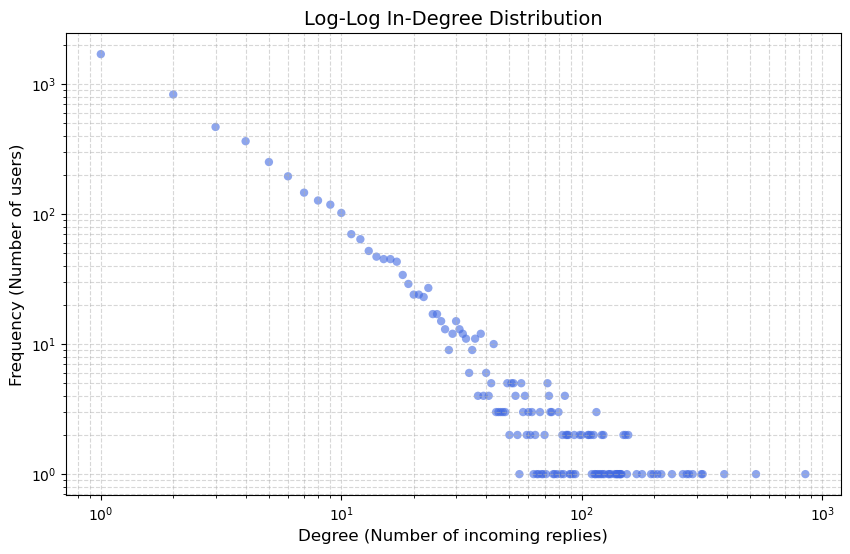

In [16]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

def plot_log_log_degree_distribution(df, filename="in_degree_distribution.png"):
    # 1. Calculate the In-Degree
    in_degree_counts = df['v'].value_counts()
    
    # 2. Count the frequency of each degree
    degree_frequencies = Counter(in_degree_counts)
    degrees = list(degree_frequencies.keys())
    counts = list(degree_frequencies.values())

    # 3. Create the Plot
    plt.figure(figsize=(10, 6))
    
    plt.scatter(degrees, counts, alpha=0.6, color='royalblue', edgecolors='none')
    
    plt.xscale('log')
    plt.yscale('log')
    
    plt.title('Log-Log In-Degree Distribution', fontsize=14)
    plt.xlabel('Degree (Number of incoming replies)', fontsize=12)
    plt.ylabel('Frequency (Number of users)', fontsize=12)
    plt.grid(True, which="both", ls="--", alpha=0.5)
    
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Plot saved as {filename}")
    
    plt.show()

# Call the function with your training data
plot_log_log_degree_distribution(pos_train, filename="in_degree_distribution_loglog.png")

### 4.3 Louvain Alogrithm

/var/folders/95/9n1yqcy54lx4gjg240ms6gxh0000gn/T/ipykernel_2024/2145485592.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis', num_communities)


Community plot saved as social_graph_communities.png


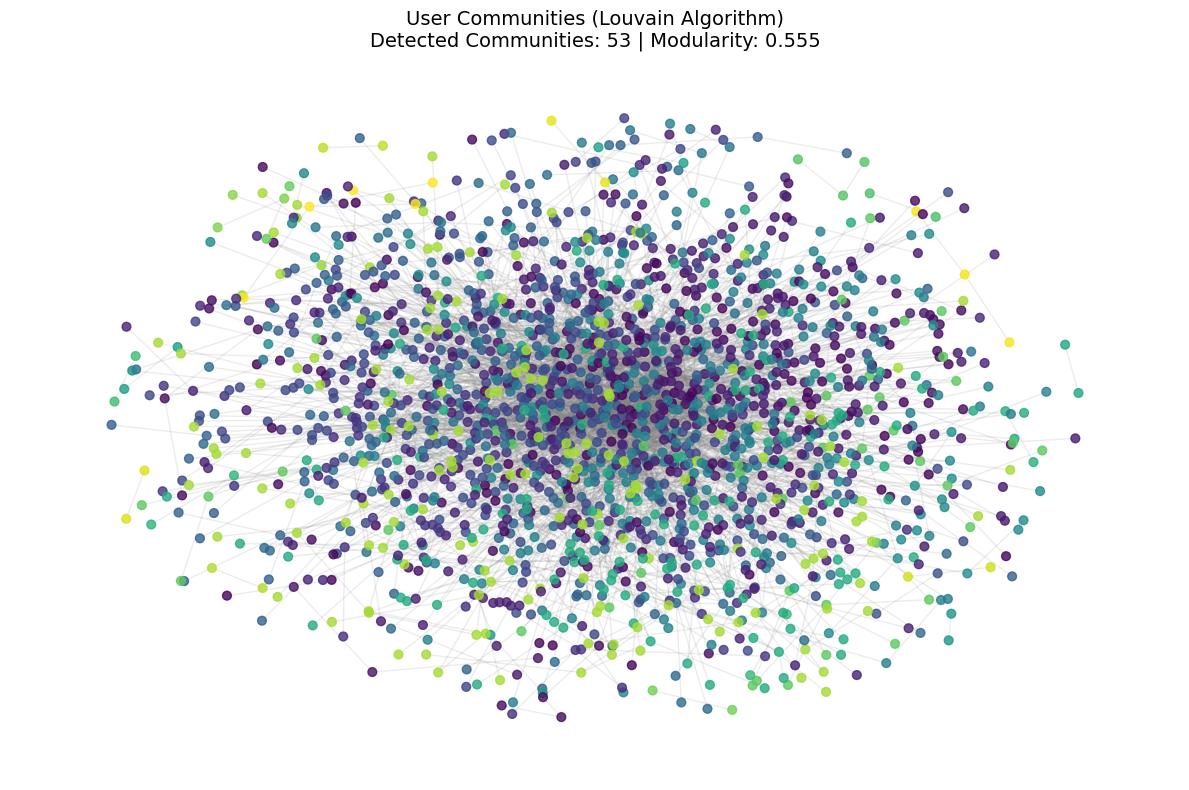

In [17]:
import networkx as nx
import community.community_louvain as community_louvain
import matplotlib.pyplot as plt

def plot_louvain_communities(df, max_edges=10000, filename="louvain_communities.png"):
    """
    Detects and visualizes structural user communities and saves the output.
    """
    # 1. Create an undirected graph
    G = nx.from_pandas_edgelist(df.head(max_edges), source='u', target='v')
    
    # 2. Compute the best partition
    partition = community_louvain.best_partition(G)
    
    # 3. Calculate layout
    pos = nx.spring_layout(G, k=0.12, seed=42)
    
    # 4. Prepare the visualization
    plt.figure(figsize=(12, 8))
    
    num_communities = max(partition.values()) + 1
    cmap = plt.cm.get_cmap('viridis', num_communities)
    
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, partition.keys(), 
                           node_size=40,
                           node_color=list(partition.values()), 
                           cmap=cmap, 
                           alpha=0.8)
    
    # Draw edges
    nx.draw_networkx_edges(G, pos, alpha=0.15, edge_color='gray')
    
    modularity = community_louvain.modularity(partition, G)
    
    plt.title(f"User Communities (Louvain Algorithm)\nDetected Communities: {num_communities} | Modularity: {modularity:.3f}", 
              fontsize=14)
    plt.axis('off')
    plt.tight_layout()

    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Community plot saved as {filename}")
    
    plt.show()

# Execute with your training interactions
plot_louvain_communities(pos_train, filename="social_graph_communities.png")